In [10]:
import os
import glob
from tqdm import tqdm
import torch

# Define the directory path
output_dir = "./test_outputs/dynamic_3_transformer_new"
all_tensors = []

# Check if directory exists
if os.path.exists(output_dir):
    pt_files = glob.glob(os.path.join(output_dir, "*.pt"))
    
    for file_path in tqdm(pt_files):
        tensor = torch.load(file_path)
        all_tensors.append(tensor)


  0%|          | 0/79 [00:00<?, ?it/s]/tmp/ipykernel_1861/1117611923.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(file_path)
100%|██████████| 79/

In [8]:
tensor.shape

torch.Size([2, 128, 49, 20])

In [11]:
tensors = torch.cat(all_tensors, dim=1).permute(1, 0, 2, 3)
tensors.shape

torch.Size([10000, 2, 49, 20])

In [12]:
torch.save(tensors, "output3.pt")

In [13]:
change_point_count = ((torch.diff(tensors, dim=2) != 0).sum(dim=-1) != 0).sum(dim=-1)

In [14]:
for i in range(4):
    mask = change_point_count[:, 0] == i
    print(f"Number of true change points = {i}")
    for j in range(11):
        num_predicted = (change_point_count[mask][:, 1] == j).sum()
        print(f"Predicted {num_predicted} times {j} change points")
    print("----------------------------------------")

Number of true change points = 0
Predicted 2217 times 0 change points
Predicted 257 times 1 change points
Predicted 36 times 2 change points
Predicted 3 times 3 change points
Predicted 1 times 4 change points
Predicted 0 times 5 change points
Predicted 0 times 6 change points
Predicted 0 times 7 change points
Predicted 0 times 8 change points
Predicted 0 times 9 change points
Predicted 0 times 10 change points
----------------------------------------
Number of true change points = 1
Predicted 367 times 0 change points
Predicted 943 times 1 change points
Predicted 678 times 2 change points
Predicted 371 times 3 change points
Predicted 135 times 4 change points
Predicted 31 times 5 change points
Predicted 13 times 6 change points
Predicted 3 times 7 change points
Predicted 0 times 8 change points
Predicted 0 times 9 change points
Predicted 0 times 10 change points
----------------------------------------
Number of true change points = 2
Predicted 104 times 0 change points
Predicted 472 t

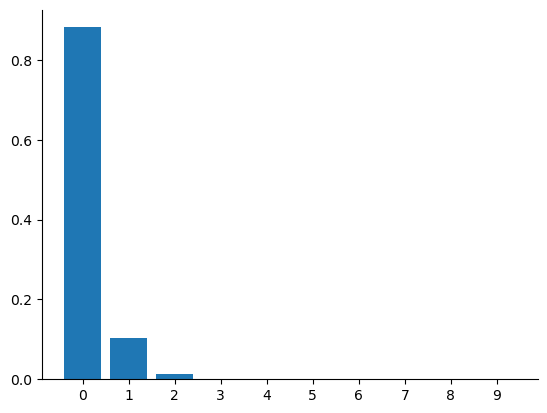

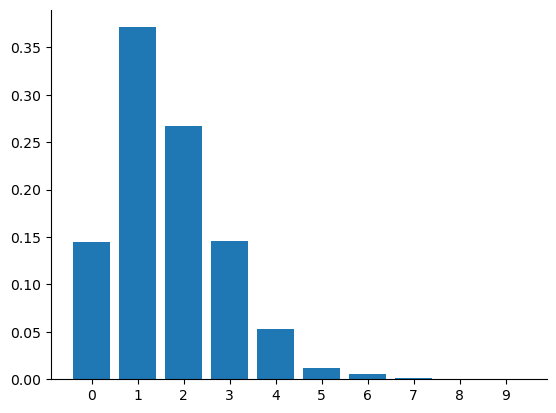

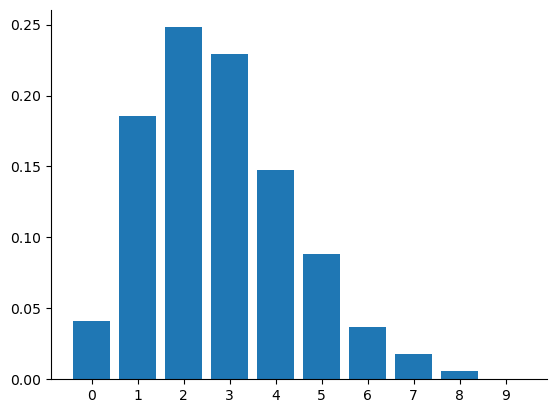

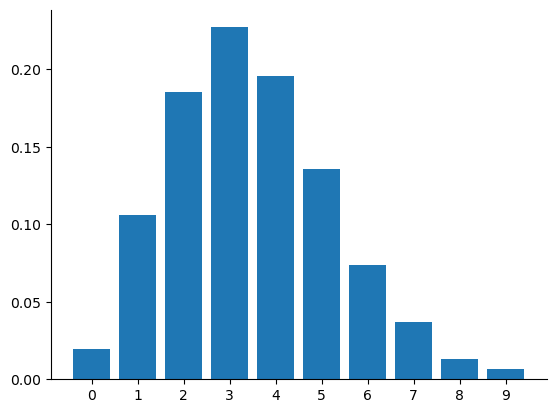

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Compute counts for true vs. predicted change points
change_point_count_cpu = change_point_count.detach().cpu()
counts = {}
c = 10
for i in range(4):
    mask = change_point_count_cpu[:, 0] == i
    counts = np.array([(change_point_count_cpu[mask][:, 1] == j).sum() for j in range(c)])
    counts = counts.astype(float) / counts.sum()

#counts /= counts
# Bar plot: true change points = 0
    plt.figure()
    l = list(range(c))
    plt.bar(l, counts)
    plt.xticks(l)
    for pos in ['right', 'top']: 
        plt.gca().spines[pos].set_visible(False) 

    plt.show()